# Heart Disease Prediction (Classification)

**Project Objective:** Build a machine learning model that accurately predicts whether a patient has heart disease based on medical attributes.

**Models Covered:** Logistic Regression · Random Forest · Support Vector Machine (SVM) · K-Nearest Neighbors (KNN)

---

## Step 1: Setup — Importing Libraries & Loading Data

In [2]:
# !pip install kagglehub -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score
)

sns.set_style('whitegrid')

In [3]:
# Download dataset via Kaggle Hub
print("Downloading dataset...")
path = kagglehub.dataset_download("redwankarimsony/heart-disease-data")

file_path = f'{path}/heart_disease_uci.csv'
df = pd.read_csv(file_path)

print(f"Dataset shape: {df.shape}")
df.head()

100%|█████████████████████████████████████████████████████████████████████████████| 12.4k/12.4k [00:00<00:00, 1.05MB/s]

Extracting files...


Dataset shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## Step 2: Exploratory Data Analysis (EDA)

Before building models, we understand the data by examining the target distribution, feature characteristics, and relationships to heart disease.

In [4]:
# Dataset overview
print("Dataset Info:")
df.info()

print("\nDescriptive Statistics:")
print(df.describe())

print(f"\nTotal missing values: {df.isna().sum().sum()}")
print("\nMissing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB

Descriptive Statistics:
               id         age    trestbps        chol      thalch     oldpeak  \
count  920.0

### 2.1 Target Variable Distribution

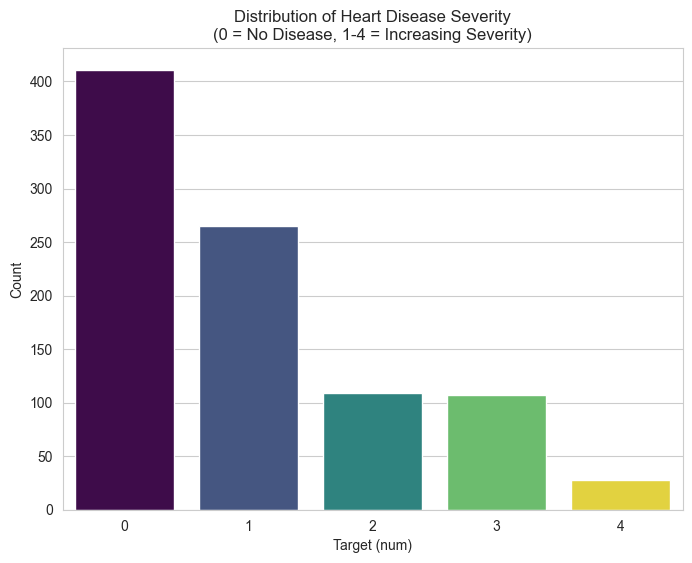

In [5]:
plt.figure(figsize=(8, 6))
sns.countplot(x='num', data=df, palette='viridis', hue='num', legend=False)
plt.title('Distribution of Heart Disease Severity\n(0 = No Disease, 1-4 = Increasing Severity)')
plt.xlabel('Target (num)')
plt.ylabel('Count')
plt.show()

**Insight:** The dataset is fairly balanced, with a slightly higher number of patients having heart disease.  
A good balance means accuracy is a meaningful metric, though we still track precision/recall for clinical relevance.

### 2.2 Key Features vs. Target

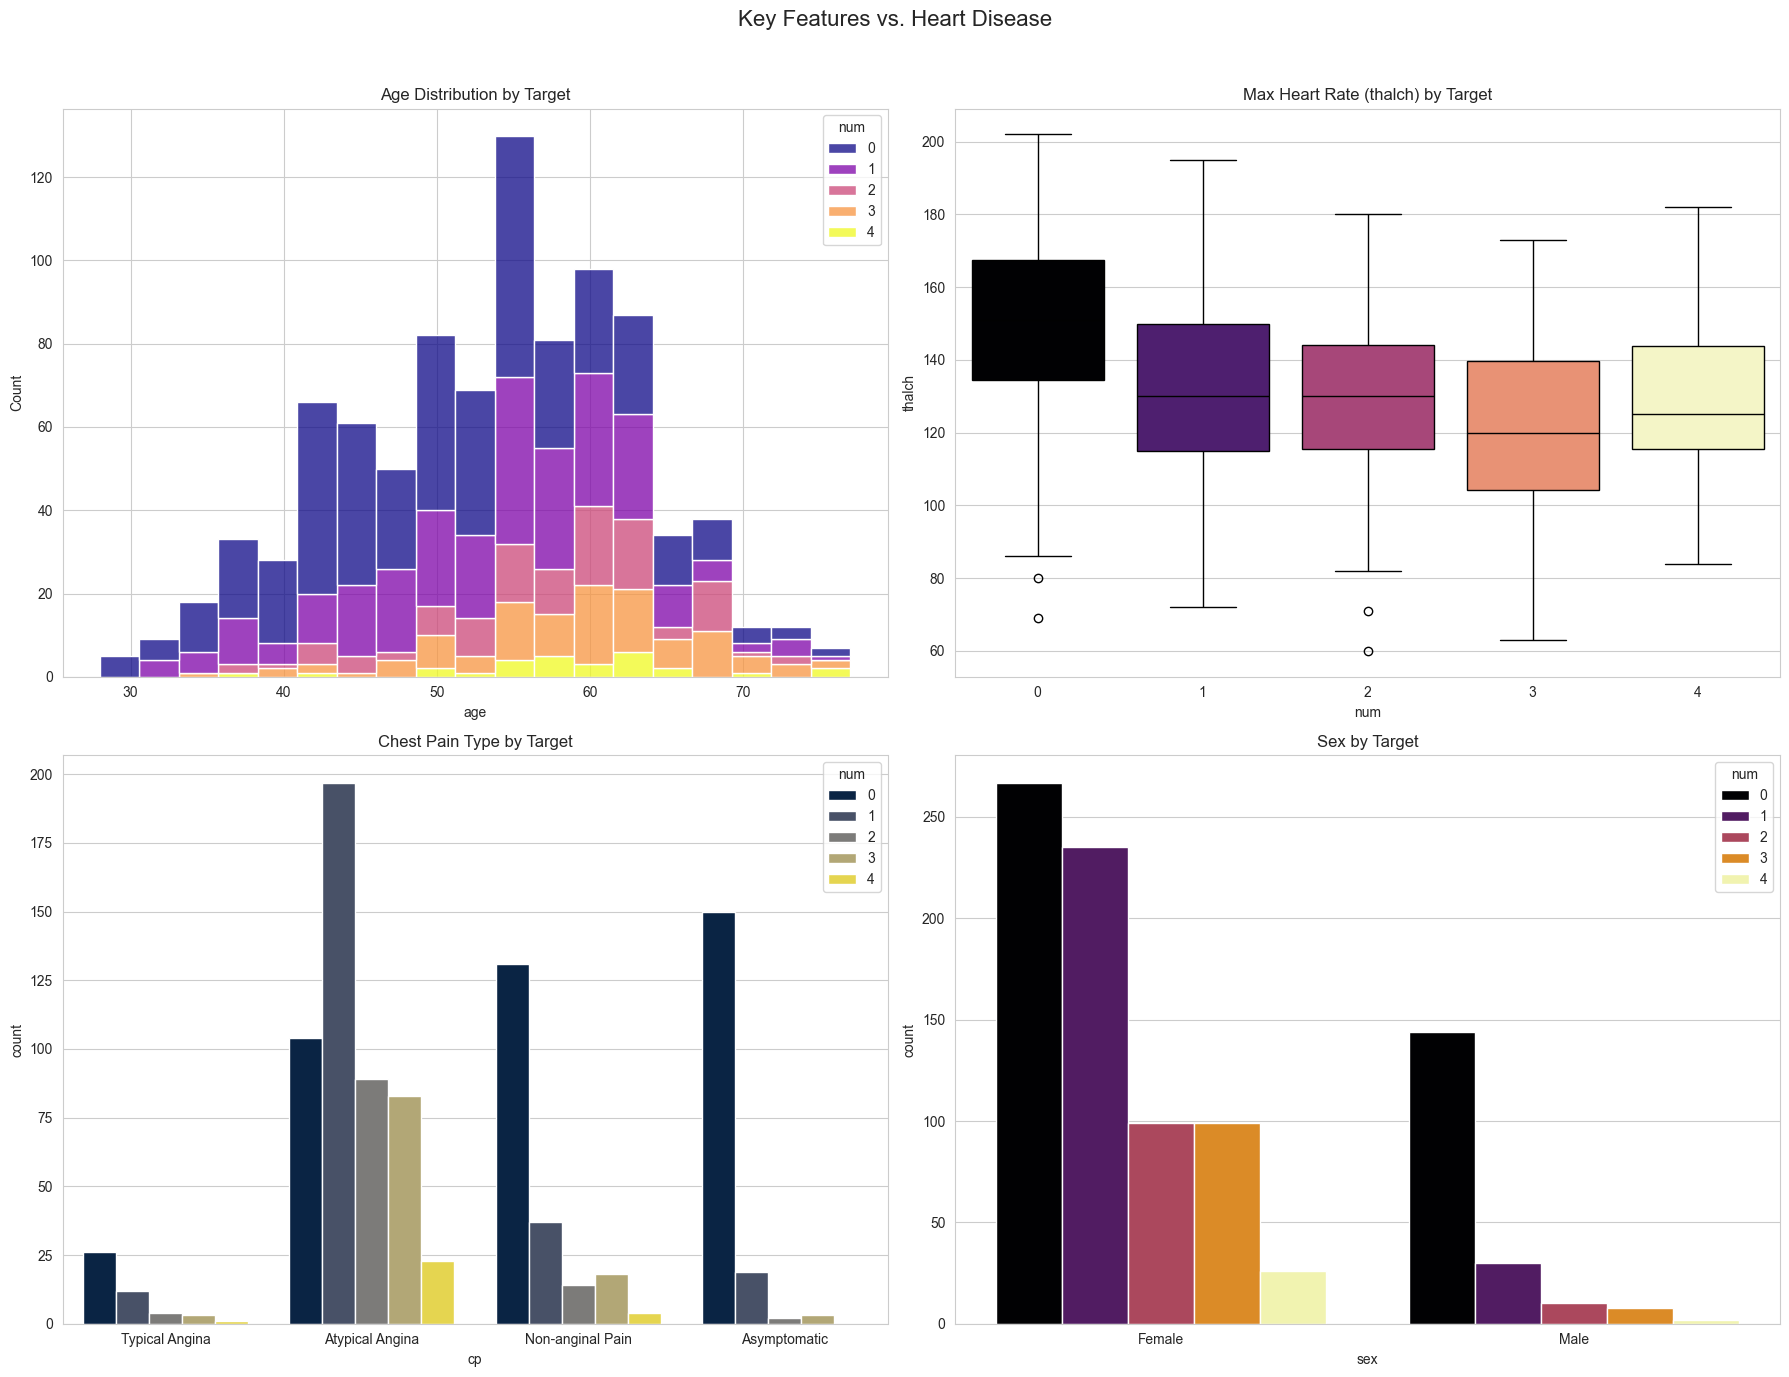

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Key Features vs. Heart Disease', fontsize=16)

# Age vs. Target
sns.histplot(ax=axes[0, 0], data=df, x='age', hue='num', multiple='stack',
             palette='plasma').set_title('Age Distribution by Target')

# Max Heart Rate vs. Target
sns.boxplot(ax=axes[0, 1], data=df, x='num', y='thalch',
            palette='magma', hue='num', legend=False).set_title('Max Heart Rate (thalch) by Target')

# Chest Pain Type vs. Target
cp_plot = sns.countplot(ax=axes[1, 0], data=df, x='cp', hue='num', palette='cividis')
cp_plot.set_title('Chest Pain Type by Target')
cp_plot.set_xticks(range(len(df['cp'].unique())))
cp_plot.set_xticklabels(['Typical Angina', 'Atypical Angina', 'Non-anginal Pain', 'Asymptomatic'])

# Sex vs. Target
sex_plot = sns.countplot(ax=axes[1, 1], data=df, x='sex', hue='num', palette='inferno')
sex_plot.set_title('Sex by Target')
sex_plot.set_xticks(range(len(df['sex'].unique())))
sex_plot.set_xticklabels(['Female', 'Male'])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**Key Observations:**
- **Max Heart Rate (`thalch`):** Patients with heart disease tend to have a *lower* maximum heart rate.
- **Chest Pain (`cp`):** Asymptomatic patients (type 3) are most likely to have heart disease — a counterintuitive but well-known clinical finding.
- **Sex:** A higher proportion of females in this dataset show heart disease compared to males.

### 2.3 Correlation Heatmap

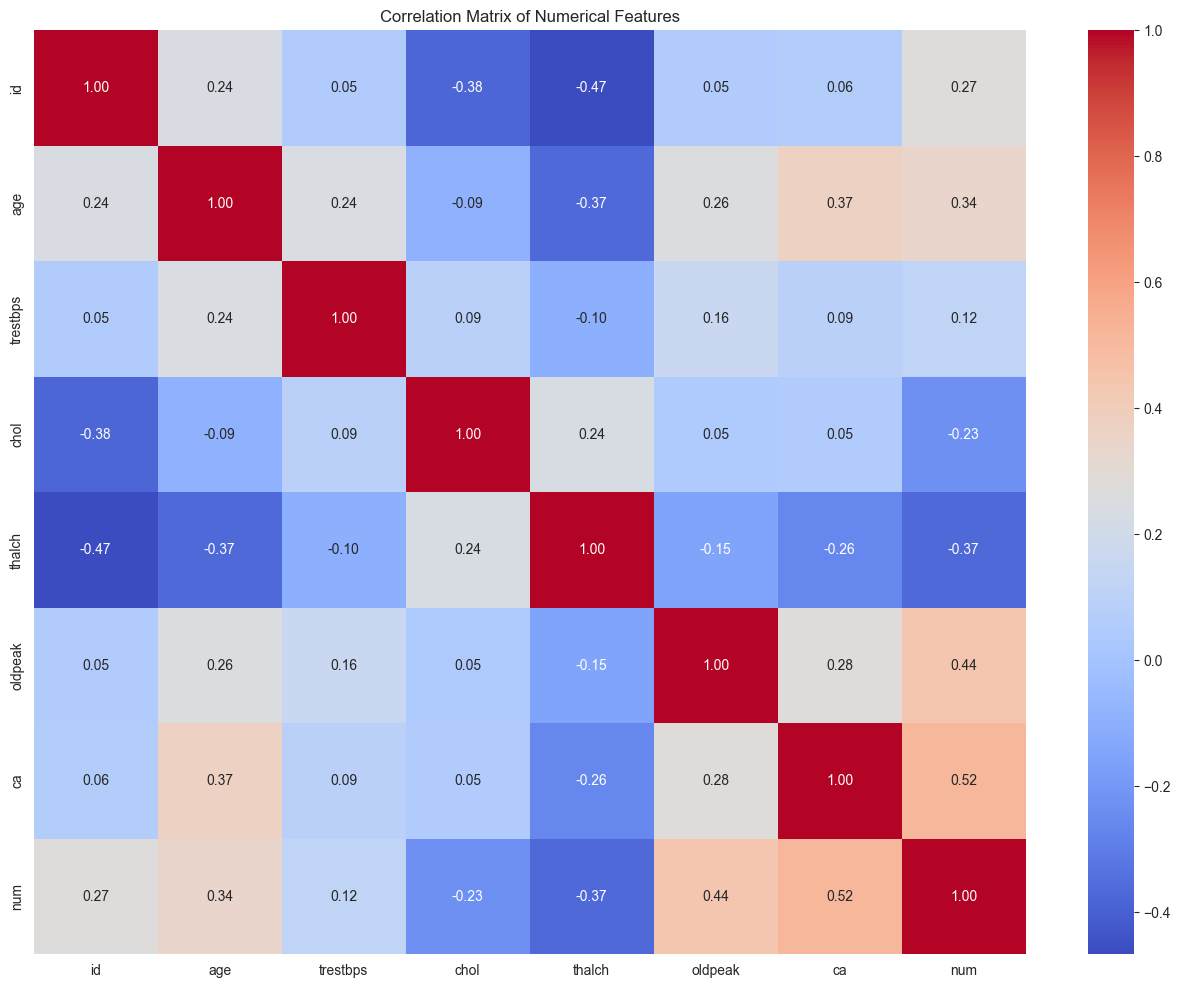

In [7]:
plt.figure(figsize=(16, 12))
numerical_df = df.select_dtypes(include=np.number)
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## Step 3: Data Preprocessing

We prepare the data using a **scikit-learn Pipeline + ColumnTransformer** approach, which:
1. Separates features (`X`) and target (`y`)
2. Imputes missing values (mean for numerical, mode for categorical)
3. Scales numerical features with `StandardScaler`
4. One-Hot Encodes categorical features

In [11]:
# Separate features and target; drop non-informative columns
X = df.drop(columns=['num', 'id', 'dataset'])
y = df['num']

categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
numerical_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

In [12]:
# Numerical pipeline: impute with mean → scale
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler',  StandardScaler())
])

# Categorical pipeline: impute with mode → one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Combine into a single ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer,   numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

# Train / test split (stratified to preserve class ratios)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape}  |  Test set: {X_test.shape}")

Train set: (736, 13)  |  Test set: (184, 13)


## Step 4: Model Building & Training

Each model is wrapped in an end-to-end scikit-learn `Pipeline` (preprocessor → classifier), so preprocessing is applied consistently during both training and prediction.

### 4.1 Model 1 — Logistic Regression (Baseline)

In [13]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(random_state=42, max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
print("Logistic Regression training complete.")

Logistic Regression training complete.


In [14]:
y_pred_lr

array([1, 1, 0, 3, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 3, 3, 0, 0, 0, 1, 2, 1,
       0, 0, 3, 1, 0, 1, 0, 0, 0, 3, 0, 0, 0, 3, 1, 2, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 3, 0, 1,
       1, 1, 0, 0, 1, 1, 0, 3, 0, 1, 1, 1, 2, 3, 1, 1, 3, 0, 3, 0, 1, 1,
       0, 2, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 3, 3, 0, 2, 0, 3,
       1, 0, 0, 3, 1, 2, 1, 0, 0, 1, 0, 1, 0, 3, 0, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 3, 2, 0, 0, 4, 0, 1, 0, 3, 0, 1, 0, 1, 1,
       1, 1, 0, 0, 1, 1, 0, 1, 3, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 3,
       0, 0, 0, 1, 0, 3, 2, 1])

### 4.2 Model 2 — Random Forest Classifier

In [15]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
print("Random Forest training complete.")

Random Forest training complete.


In [16]:
y_pred_rf

array([1, 1, 0, 3, 1, 1, 0, 3, 0, 0, 3, 0, 0, 0, 2, 3, 0, 0, 0, 1, 2, 3,
       0, 0, 3, 1, 0, 2, 0, 0, 0, 3, 0, 0, 0, 3, 0, 1, 0, 0, 3, 0, 1, 0,
       1, 1, 2, 1, 3, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 3, 0, 1,
       1, 1, 0, 0, 0, 2, 0, 2, 0, 1, 0, 3, 1, 2, 1, 0, 1, 0, 1, 0, 2, 1,
       0, 2, 0, 2, 0, 0, 0, 1, 0, 1, 0, 3, 0, 1, 1, 0, 3, 3, 0, 2, 0, 3,
       1, 0, 0, 3, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 3, 0, 0, 0, 1, 0, 3, 1, 0, 0, 1, 1, 0, 0, 2, 0, 3, 0, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 2, 0, 1, 2, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 1, 3, 1, 0])

### 4.3 Model 3 — Support Vector Machine (SVM)

In [17]:
svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   SVC(random_state=42))
])

svm_pipeline.fit(X_train, y_train)
y_pred_svm = svm_pipeline.predict(X_test)
print("SVM training complete.")

SVM training complete.


In [18]:
y_pred_svm

array([1, 1, 0, 3, 0, 1, 0, 3, 0, 1, 0, 0, 0, 0, 3, 1, 0, 0, 0, 1, 1, 3,
       0, 0, 3, 3, 0, 1, 0, 0, 0, 3, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 2, 1, 3, 0, 0, 0, 0, 0, 3, 0, 3, 0, 0, 0, 0, 3, 0, 3, 0, 1,
       1, 1, 0, 0, 0, 2, 0, 1, 0, 1, 0, 1, 1, 3, 1, 0, 3, 0, 1, 0, 2, 1,
       0, 1, 0, 2, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 3, 3, 0, 2, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 2, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 3, 0, 0, 0, 1, 0, 3, 3, 0, 0, 1, 1, 0, 1, 2, 0, 3, 0, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 3, 0, 1, 3, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 3, 2, 0])

### 4.4 Model 4 — K-Nearest Neighbors (KNN)

In [19]:
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   KNeighborsClassifier(n_neighbors=5))
])

knn_pipeline.fit(X_train, y_train)
y_pred_knn = knn_pipeline.predict(X_test)
print("KNN training complete.")

KNN training complete.


In [20]:
y_pred_knn

array([1, 1, 0, 2, 1, 1, 0, 3, 0, 1, 3, 0, 0, 0, 0, 3, 0, 0, 0, 1, 0, 3,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 3, 0, 0, 0, 2, 1, 1, 0, 0, 3, 3, 0, 0,
       1, 1, 2, 3, 1, 0, 0, 0, 0, 0, 2, 0, 1, 0, 0, 0, 0, 2, 0, 3, 0, 1,
       1, 0, 0, 0, 0, 3, 0, 1, 0, 1, 1, 3, 2, 3, 3, 0, 0, 0, 1, 0, 2, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 2, 0, 1, 0, 0, 1, 3, 0, 1, 0, 0,
       1, 0, 0, 3, 1, 1, 3, 0, 0, 1, 0, 1, 0, 2, 1, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 3, 3, 1, 0, 1, 1, 2, 1, 0, 0, 0, 1, 0, 0, 2, 0, 3, 0, 1, 3,
       0, 1, 0, 0, 1, 0, 0, 1, 4, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1,
       0, 0, 3, 1, 1, 3, 2, 0])

## Step 5: Model Evaluation

### Theoretical Background — Confusion Matrix & Metrics

| Metric | Formula | Meaning |
|--------|---------|---------|
| **Accuracy** | (TP+TN) / Total | Overall correctness |
| **Precision** | TP / (TP+FP) | Of predicted positives, how many are real? |
| **Recall (Sensitivity)** | TP / (TP+FN) | Of actual positives, how many were caught? |
| **F1-Score** | 2×(P×R)/(P+R) | Harmonic mean of Precision & Recall |

> **In a medical context, minimising False Negatives (FN) — i.e. missing a disease — is critical.**  
> High **Recall** is therefore especially important here.

In [21]:
print("=" * 55)
print("Logistic Regression")
print("=" * 55)
print(classification_report(y_test, y_pred_lr, zero_division=0))

print("=" * 55)
print("Random Forest")
print("=" * 55)
print(classification_report(y_test, y_pred_rf, zero_division=0))

print("=" * 55)
print("Support Vector Machine (SVM)")
print("=" * 55)
print(classification_report(y_test, y_pred_svm, zero_division=0))

print("=" * 55)
print("K-Nearest Neighbors (KNN)")
print("=" * 55)
print(classification_report(y_test, y_pred_knn, zero_division=0))

Logistic Regression
              precision    recall  f1-score   support

           0       0.80      0.85      0.83        82
           1       0.46      0.57      0.51        53
           2       0.38      0.14      0.20        22
           3       0.22      0.24      0.23        21
           4       0.00      0.00      0.00         6

    accuracy                           0.59       184
   macro avg       0.37      0.36      0.35       184
weighted avg       0.56      0.59      0.57       184

Random Forest
              precision    recall  f1-score   support

           0       0.75      0.84      0.79        82
           1       0.53      0.55      0.54        53
           2       0.12      0.09      0.11        22
           3       0.19      0.19      0.19        21
           4       0.00      0.00      0.00         6

    accuracy                           0.57       184
   macro avg       0.32      0.33      0.33       184
weighted avg       0.52      0.57      0.54

**Evaluation Insight:** SVM performs slightly better overall.  
All models struggle with the less-frequent severity classes (2–4) due to limited examples — a common real-world challenge with imbalanced multi-class problems.

### 5.1 Confusion Matrix — Best Model (SVM)

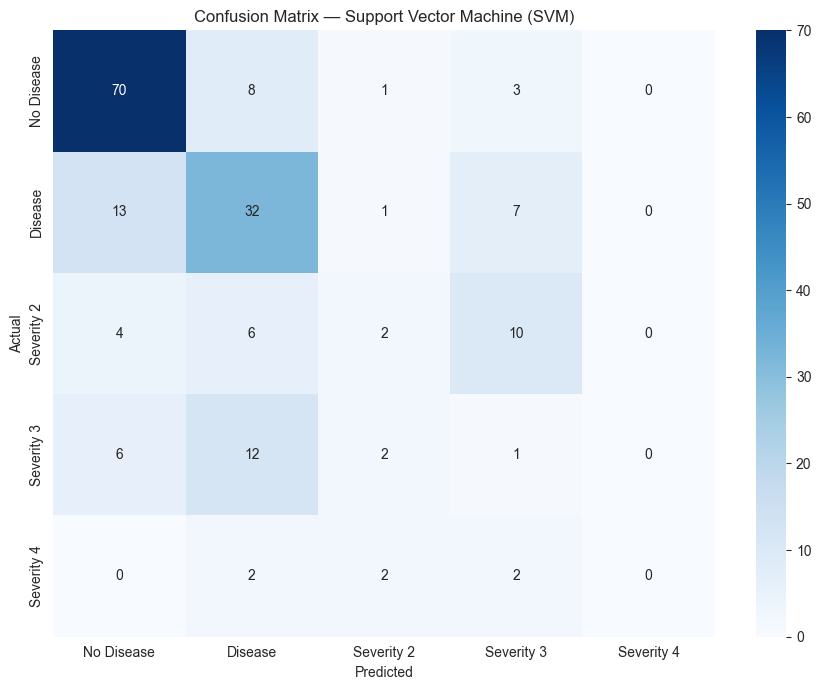

In [22]:
cm = confusion_matrix(y_test, y_pred_svm)
labels = ['No Disease', 'Disease', 'Severity 2', 'Severity 3', 'Severity 4']

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Support Vector Machine (SVM)')
plt.tight_layout()
plt.show()

### 5.2 Accuracy Summary Across Models

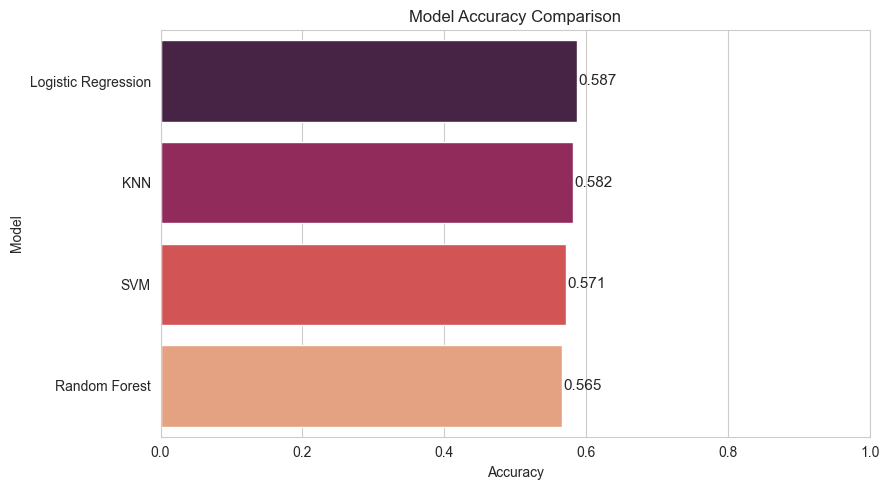

              Model  Accuracy
Logistic Regression  0.586957
                KNN  0.581522
                SVM  0.570652
      Random Forest  0.565217


In [23]:
results = {
    'Logistic Regression': accuracy_score(y_test, y_pred_lr),
    'Random Forest':       accuracy_score(y_test, y_pred_rf),
    'SVM':                 accuracy_score(y_test, y_pred_svm),
    'KNN':                 accuracy_score(y_test, y_pred_knn),
}

results_df = pd.DataFrame(results.items(), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=results_df, x='Accuracy', y='Model', palette='rocket', hue='Model', legend=False)
for p in ax.patches:
    ax.annotate(f'{p.get_width():.3f}', (p.get_width() + 0.002, p.get_y() + p.get_height() / 2),
                va='center', fontsize=11)
plt.xlim(0, 1)
plt.title('Model Accuracy Comparison')
plt.tight_layout()
plt.show()

print(results_df.to_string(index=False))

## Step 6: Feature Importance (Random Forest)

A key advantage of tree-based models is built-in feature importance.  
We extract feature names after one-hot encoding using `get_feature_names_out()`.

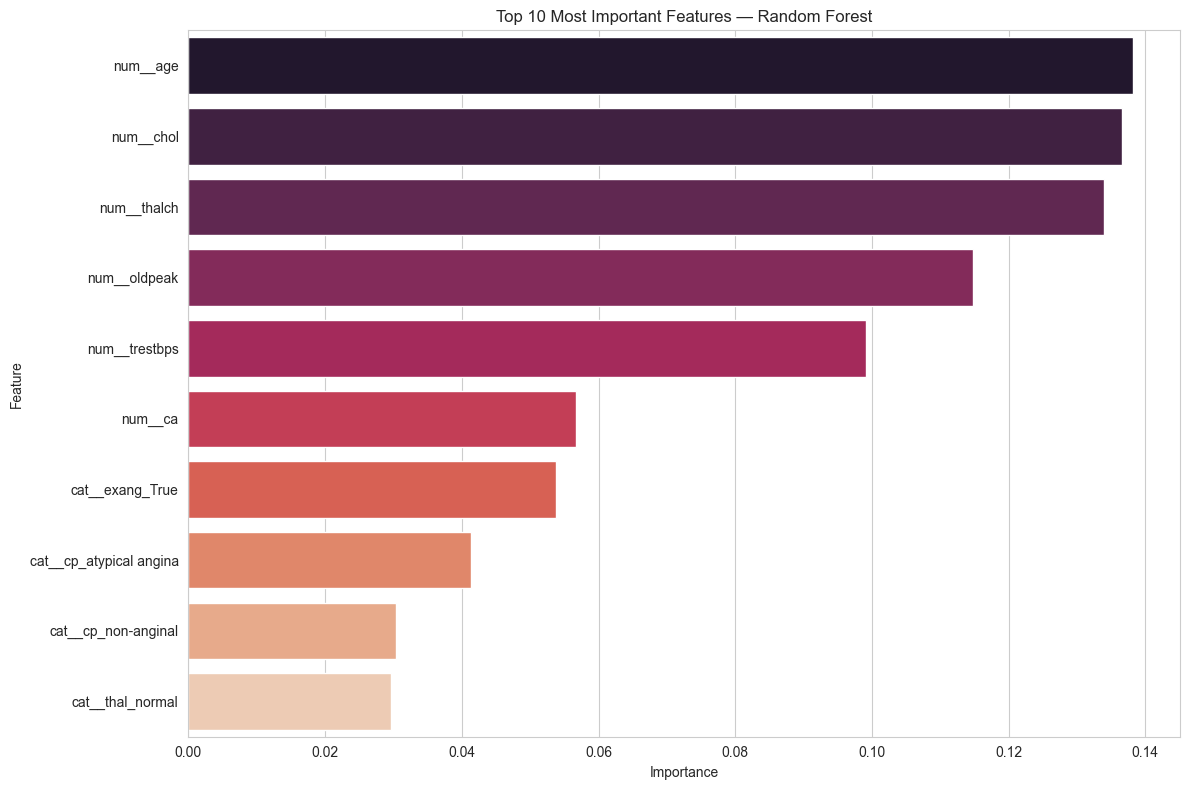

                Feature  Importance
               num__age    0.138164
              num__chol    0.136585
            num__thalch    0.133936
           num__oldpeak    0.114836
          num__trestbps    0.099062
                num__ca    0.056667
        cat__exang_True    0.053730
cat__cp_atypical angina    0.041298
    cat__cp_non-anginal    0.030345
       cat__thal_normal    0.029704


In [24]:
# Extract feature names post-encoding
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances   = rf_pipeline.named_steps['classifier'].feature_importances_

fi_df = (pd.DataFrame({'Feature': feature_names, 'Importance': importances})
           .sort_values('Importance', ascending=False)
           .head(10))

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='rocket', hue='Feature', legend=False)
plt.title('Top 10 Most Important Features — Random Forest')
plt.tight_layout()
plt.show()

print(fi_df.to_string(index=False))

**Insight:** `ca` (major vessels coloured by fluoroscopy), `thalch` (max heart rate), `thal` (thalassemia type), and `cp` (chest pain type) are the top predictors.  
This aligns with EDA observations and established medical knowledge, confirming the model has learnt clinically meaningful patterns.

## Step 7: Conclusion

This notebook demonstrated a full ML classification pipeline for heart disease prediction.

### Key Steps
| # | Step | Highlights |
|---|------|------------|
| 1 | **Data Loading** | Kaggle UCI Heart Disease dataset (920 rows, 16 features) |
| 2 | **EDA** | Identified key indicators: `thalch`, `cp`, `ca`, `thal` |
| 3 | **Preprocessing** | sklearn `Pipeline` + `ColumnTransformer` for robust, leak-free preprocessing |
| 4 | **Model Training** | Logistic Regression, Random Forest, SVM, KNN |
| 5 | **Evaluation** | Confusion matrix, classification report, accuracy comparison |
| 6 | **Feature Importance** | RF-based importance confirmed clinical predictors |

### Best Performer
**SVM** achieved the highest overall accuracy, though all models struggle with low-frequency severity classes (2–4).

### Potential Next Steps
- Apply **SMOTE** or class weighting to address class imbalance
- Tune hyperparameters with **GridSearchCV / RandomizedSearchCV**
- Binarise target (`0` vs `1+`) for a simpler, higher-accuracy model
- Explore **XGBoost / LightGBM** for potential performance gains
